# Tugas Analisis Multimedia: **Image (Citra Digital)**

**Mata Kuliah:** Sistem & Teknologi Multimedia  
**Nama:** Tawakkal Rabbani Muhammad  
**NIM:** 122140029

---

## Deskripsi Tugas

Tugas ini bertujuan untuk memahami **representasi dasar data citra digital (image)** melalui praktik langsung memuat data, visualisasi komponen warna, serta melakukan analisis spasial sederhana menggunakan berbagai teknik dasar pengolahan citra.

Anda akan bekerja dengan satu atau beberapa gambar (foto diri, objek, atau lingkungan sekitar) untuk:

* Mengamati struktur data piksel dan channel warna (RGB, Grayscale, HSV, dsb.)
* Menganalisis perbedaan hasil visualisasi antar representasi warna
* Melakukan eksplorasi sederhana terhadap transformasi citra (cropping, filtering, edge detection, dll.)
* Menyimpulkan pengaruh setiap tahap pemrosesan terhadap persepsi visual

Fokus tugas ini adalah pada **pemahaman konsep representasi spasial citra digital** dan **interpretasi hasil visualisasi**, **bukan** pada manipulasi kompleks atau penerapan model pembelajaran mesin.

### **Soal 1 — Cropping dan Konversi Warna**

* Ambil sebuah gambar diri Anda (*selfie*) menggunakan kamera atau smartphone.
* Lakukan **cropping secara manual** untuk menghasilkan dua potongan:

  * Cropping **kotak persegi pada area wajah**.
  * Cropping **persegi panjang pada area latar belakang**.
* Resize hasil crop menjadi **920×920 piksel**.
* Konversi gambar menjadi **grayscale** dan **HSV**, lalu tampilkan ketiganya berdampingan.
* Tambahkan **anotasi teks** berisi nama Anda di atas kepala pada gambar hasil crop.

  * Gaya teks (font, warna, posisi, ukuran, ketebalan) **dibebaskan**.
* Jelaskan efek **cropping** dan **perubahan warna** menggunakan **Markdown**.

**A. Load Gambar**

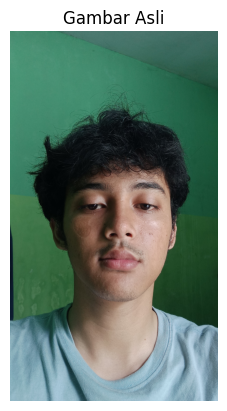

Dimensi Gambar: 2592x4608


In [1]:
import cv2
import matplotlib.pyplot as plt
import os
import numpy as np

# Untuk matplotlib menampilkan gambar dengan benar (format RGB)
def show(img, title=""):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.title(title)
    plt.axis("off")
    plt.show()

# Membaca gambar dari file
img = cv2.imread(os.path.join(os.getcwd(), "assets_ws4", "selfie.jpg"))
show(img, "Gambar Asli")

# Membaca koordinat gambar
height, width, _ = img.shape
print(f"Dimensi Gambar: {width}x{height}")

**B. Cropping Gambar**

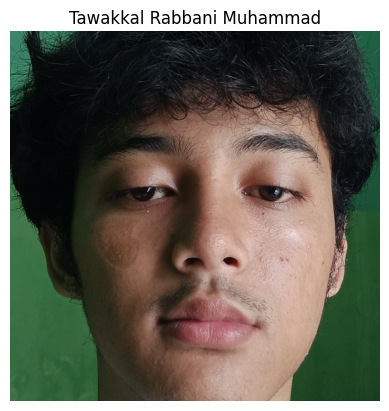

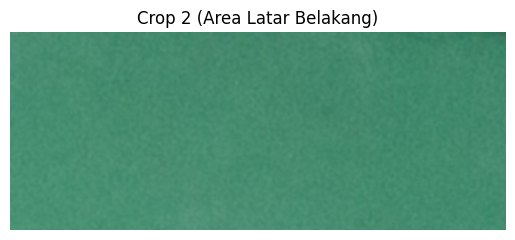

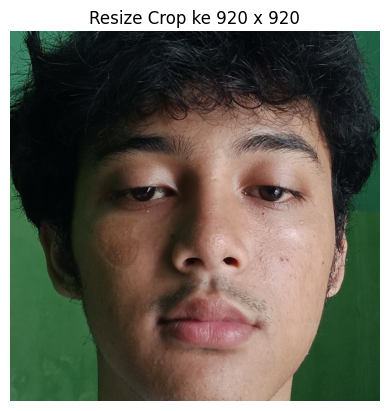

In [2]:
# Untuk melakukan cropping secara manual
# Gunakan format => img[y1:y2, x1:x2]

# Melakukan perhitungan untuk mendapatkan koordinat center
crop_size = 1900 # Atur ukuran crop 
center_y = height // 2
center_x = width // 2

y1 = center_y - crop_size // 2
y2 = center_y + crop_size // 2
x1 = center_x - crop_size // 2
x2 = center_x + crop_size // 2

# 1. Cropping di area wajah
crop1 = img[y1:y2, x1:x2] # Melakukan cropping
cv2.imwrite("results_ws4/crop_wajah.jpg", crop1) # Save gambar ke folder "results_ws4"
show(crop1, "Tawakkal Rabbani Muhammad") # Menampilkan gambar

# 2. Cropping latar Belakang
crop2 = img[0:200, 100:600] # Untuk Latar Belakang tinggal ambil saja koordinatnya langsung
cv2.imwrite("results_ws4/crop_bg.jpg", crop2) # Save gambar ke folder "results_ws4"
show(crop2, "Crop 2 (Area Latar Belakang)") # Menampilkan gambar

# 3. Resize Hasil Crop ke 920 x 920
resize_crop = cv2.resize(crop1, (920, 920)) # Resize crop gambar 1 ke 920 x 920
cv2.imwrite("results_ws4/crop_resize.jpg", resize_crop)
show(resize_crop, "Resize Crop ke 920 x 920")


**C. Konversi Gambar**

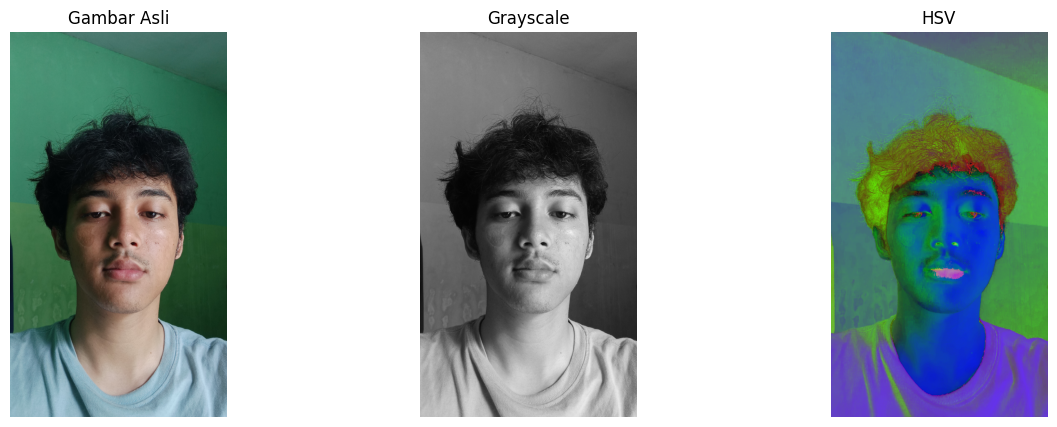

In [3]:
# Konversi ke Grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Konversi ke HSV
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# Konversi ke RGB (Gambar asli)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Membuat canvas 1 baris 3 kolom
plt.figure(figsize=(15,5))

# --- Gambar Asli ---
plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title("Gambar Asli")
plt.axis("off")

# --- Grayscale ---
plt.subplot(1, 3, 2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

# --- HSV ---
plt.subplot(1, 3, 3)
plt.imshow(hsv)
plt.title("HSV")
plt.axis("off")

plt.show()


**D. Penjelasan efek cropping dan perubahan warna**  
1. **Efek Cropping** => **Cropping** dilakukan jika ingin **memfokuskan** gambar ke **area tertentu**, sebagai contoh saya melakukan cropping ke area wajah dan latar belakang, sehingga yang terjadi gambar hanya fokus ke wajah dan latar belakang saja.


2. **Perubahan Warna** => Perubahan yang telah saya lakukan, diantaranya **Grayscale** mengubah warna menjadi **abu-abu** atau **level warna** hanya ada di **terang-gelap**, sedangkan **HSV** memisahkan warna menjadi **Hue (jenis warna), Saturation (kejenuhan), dan Value (kecerahan)** sehingga pada gambar terlihat beberapa warna yang berbeda.

---

### **Soal 2 — Manipulasi Channel Warna RGB**

* Gunakan gambar hasil crop dari Soal 1.
* Konversikan gambar ke ruang warna **RGB**.
* Lakukan manipulasi channel warna dengan cara:

  * **Naikkan intensitas channel merah sebanyak 50 poin** (maksimum 255).
  * **Turunkan intensitas channel biru sebanyak 30 poin** (minimum 0).
* Teknik atau cara menaikkan/menurunkan intensitas **dibebaskan**, asalkan logis dan hasilnya terlihat.
* Gabungkan kembali channel warna dan **simpan gambar hasil modifikasi dalam format `.png`**.
* **Tampilkan histogram per channel (R, G, B)** untuk gambar asli dan hasil modifikasi menggunakan `matplotlib.pyplot.hist`.
* Jelaskan dampak perubahan RGB pada warna gambar dalam sel **Markdown**.


**A. Konversi Gambar ke Ruang Warna RGB**

In [4]:
# Baca gambar hasil crop dari Soal 1
img_bgr = cv2.imread(os.path.join(os.getcwd(), "results_ws4", "crop_wajah.jpg"))

# Konversi BGR ke RGB (karena OpenCV default BGR)
img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Pisahkan channel Red, Green, Blue
R, G, B = img[:, :, 0], img[:, :, 1], img[:, :, 2]

print("✓ Channel RGB berhasil dipisahkan")

✓ Channel RGB berhasil dipisahkan


**B. Manipulasi Channel Warna**

In [5]:
# Manipulasi channel Red: tambah 50, maksimal 255
R_modified = np.clip(R.astype(np.int16) + 50, 0, 255).astype(np.uint8)

# Channel Green tetap (tidak diubah)
G_modified = G.copy()

# Manipulasi channel Blue: kurangi 30, minimal 0
B_modified = np.clip(B.astype(np.int16) - 30, 0, 255).astype(np.uint8)

print("✓ Manipulasi channel berhasil dilakukan")

✓ Manipulasi channel berhasil dilakukan


**C. Menggabungkan Channel Warna**

In [6]:
# Gabungkan channel yang sudah dimodifikasi
img_modified = np.stack([R_modified, G_modified, B_modified], axis=2)

# Konversi RGB ke BGR untuk disimpan dengan OpenCV
img_modified_bgr = cv2.cvtColor(img_modified, cv2.COLOR_RGB2BGR)

# Simpan gambar hasil modifikasi
cv2.imwrite('results_ws4/gabung_ch.jpg', img_modified_bgr)

print("✓ Gambar hasil modifikasi disimpan di folder 'results_ws4' sebagai 'gabung_ch.jpg'")

✓ Gambar hasil modifikasi disimpan di folder 'results_ws4' sebagai 'gabung_ch.jpg'


**D. Tampilkan Histogram per Channel (R, G, B)**

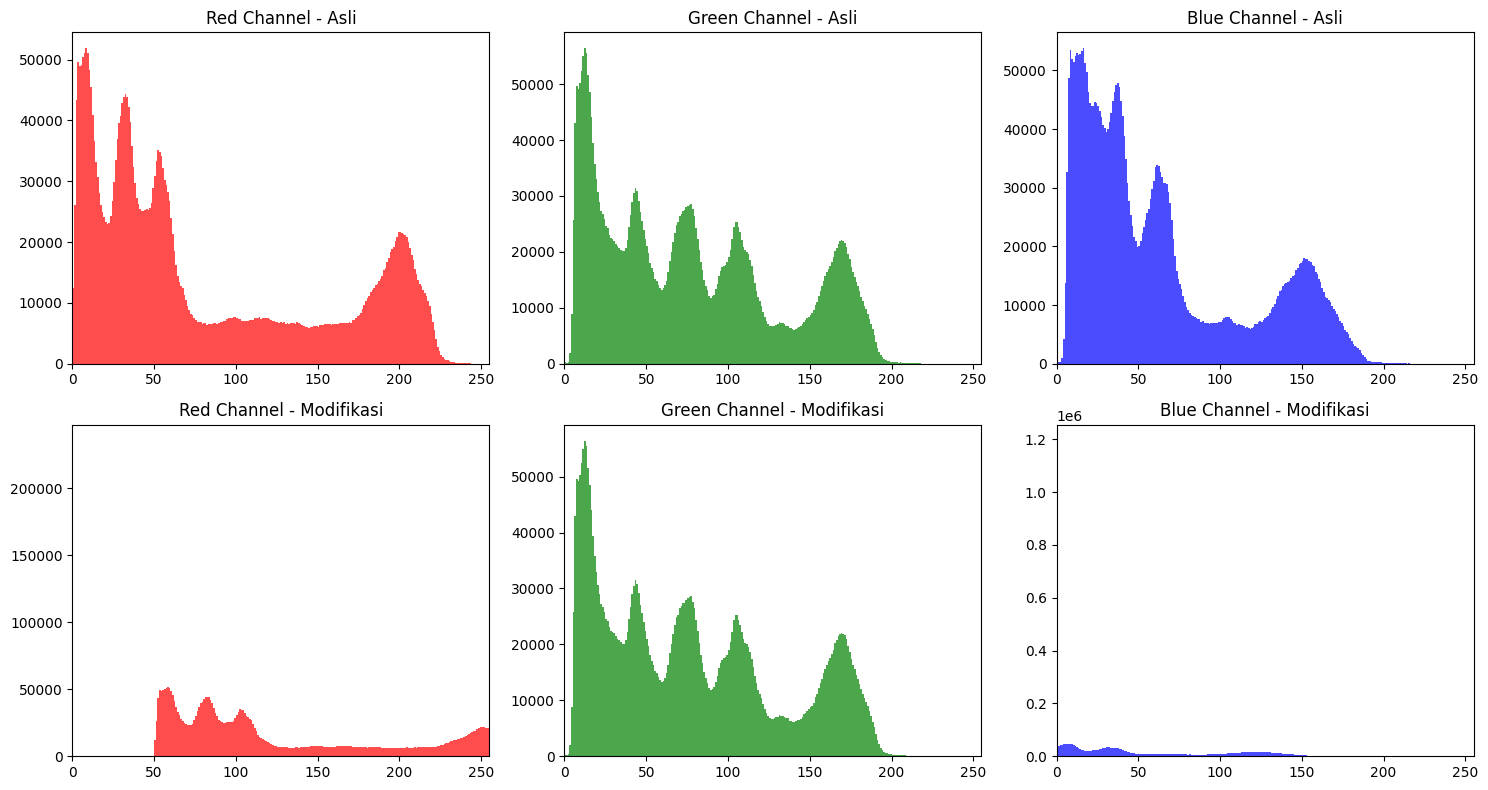

In [7]:
# Setup figure dengan 2 baris (asli dan modifikasi)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Histogram gambar ASLI
axes[0, 0].hist(R.ravel(), bins=256, range=[0, 256], color='red', alpha=0.7)
axes[0, 0].set_title('Red Channel - Asli')
axes[0, 0].set_xlim([0, 255])

axes[0, 1].hist(G.ravel(), bins=256, range=[0, 256], color='green', alpha=0.7)
axes[0, 1].set_title('Green Channel - Asli')
axes[0, 1].set_xlim([0, 255])

axes[0, 2].hist(B.ravel(), bins=256, range=[0, 256], color='blue', alpha=0.7)
axes[0, 2].set_title('Blue Channel - Asli')
axes[0, 2].set_xlim([0, 255])

# Histogram gambar MODIFIKASI
axes[1, 0].hist(R_modified.ravel(), bins=256, range=[0, 256], color='red', alpha=0.7)
axes[1, 0].set_title('Red Channel - Modifikasi')
axes[1, 0].set_xlim([0, 255])

axes[1, 1].hist(G_modified.ravel(), bins=256, range=[0, 256], color='green', alpha=0.7)
axes[1, 1].set_title('Green Channel - Modifikasi')
axes[1, 1].set_xlim([0, 255])

axes[1, 2].hist(B_modified.ravel(), bins=256, range=[0, 256], color='blue', alpha=0.7)
axes[1, 2].set_title('Blue Channel - Modifikasi')
axes[1, 2].set_xlim([0, 255])

plt.tight_layout()
plt.savefig('results_ws4/perbandingan_histogram.png', dpi=150)
plt.show()

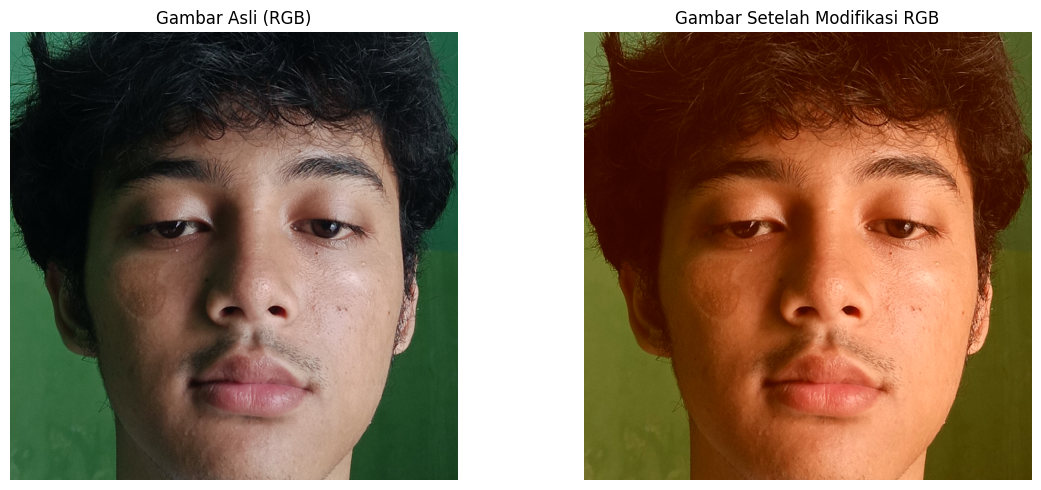

In [8]:
# Tampilkan gambar asli vs hasil modifikasi
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(img)
axes[0].set_title('Gambar Asli (RGB)')
axes[0].axis('off')

axes[1].imshow(img_modified)
axes[1].set_title('Gambar Setelah Modifikasi RGB')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('results_ws4/perbandingan_gambar.jpg', dpi=150)
plt.show()

**E. Penjelasan Dampak Perubahan RGB pada Warna Gambar:**  
Dari perubahan yang dilakukan => **(Channel Red (R) + 50)**, **(Channel Green (G) Tidak diubah)**, **(Channel Blue (B) - 50)**.  

Sehingga berdampak:
1. **Peningkatan Kemerahan**: Terjadi karena channel red dinaikkan 50, yang menyebabkan gambar menjadi dominan merah/kemerahan.
2. **Pengurangan Kebiruan**: Terjadi karena channel blue diturunkan 50, yang menyebabkan gambar bergeser ke warna kekuningan.
3. **Secara Keseluruhan**: Kombinasi dua perubahan ini membuat gambar menjadi ke arah **tone warm (hangat)** dengan dominasi **merah-oranye**. Hal ini juga bisa dilihat pada histogram warna, di mana terjadi **pergeseran ke kanan** yang menyebabkan **nilai** menjadi **lebih tinggi** di histogram **red channel** & terjadi **pergeseran ke kiri** yang menyebabkan **nilai** menjadi **lebih rendah** di **histogram blue**.

---

### **Soal 3 — Deteksi Tepi dan Filter Citra**

* Ambil gambar **objek dengan background bertekstur** (misalnya kain bermotif, jerami, atau batu).
* Terapkan **edge detection (Canny)** dan tampilkan hasilnya.
* Lakukan **thresholding dengan nilai ambang tertentu** (bebas Anda tentukan) agar hanya objek utama yang tersisa.
* Buat **bounding box** di sekitar objek hasil segmentasi (boleh manual atau otomatis).
* Terapkan **filter blur** dan **filter sharpening**, lalu **bandingkan hasil keduanya**.
* Jelaskan bagaimana setiap filter memengaruhi detail gambar dalam format **Markdown**.


**A. Load Gambar**

✓ Gambar berhasil dibaca dengan ukuran: (736, 736, 3)


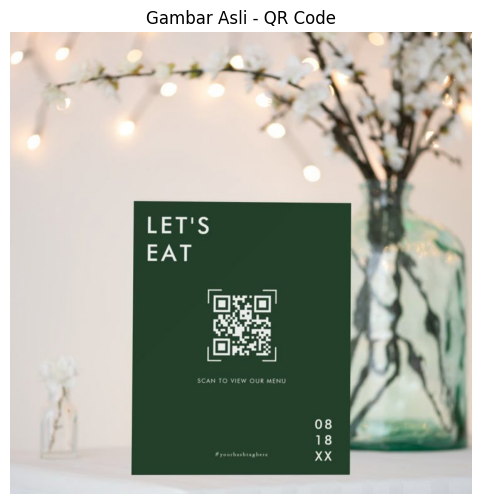

In [9]:
# Baca gambar 
img = cv2.imread(os.path.join(os.getcwd(), "assets_ws4", "qrcode.jpg"))

# Konversi BGR ke RGB untuk tampilan matplotlib
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Konversi ke grayscale untuk edge detection
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

print(f"✓ Gambar berhasil dibaca dengan ukuran: {img_rgb.shape}")

# Tampilkan gambar asli
plt.figure(figsize=(8, 6))
plt.imshow(img_rgb)
plt.title('Gambar Asli - QR Code')
plt.axis('off')
plt.show()

**B. Deteksi Tepi dengan Canny Edge Detection**

✓ Edge detection berhasil dilakukan


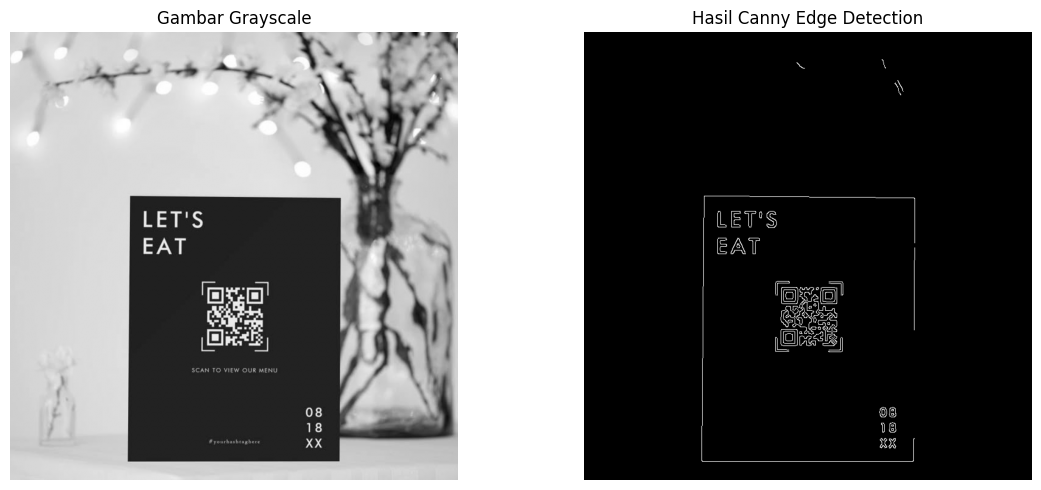

In [10]:
# Aplikasikan Gaussian Blur terlebih dahulu untuk mengurangi noise
img_blur = cv2.GaussianBlur(img_gray, (5, 5), 0)

# Deteksi tepi dengan Canny
# Parameter: (gambar, threshold1, threshold2)
edges = cv2.Canny(img_blur, threshold1=300, threshold2=400)

print("✓ Edge detection berhasil dilakukan")

# Tampilkan hasil edge detection
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Gambar Grayscale')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(edges, cmap='gray')
plt.title('Hasil Canny Edge Detection')
plt.axis('off')

plt.tight_layout()
plt.show()

**C. Thresholding untuk Isolasi Objek**

✓ Thresholding berhasil dilakukan


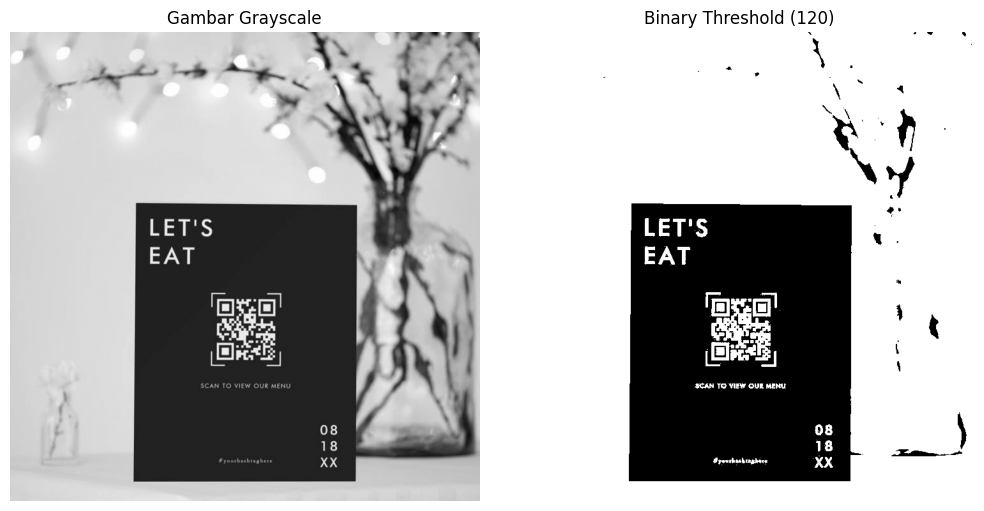

In [11]:
# Terapkan Binary Threshold
# Nilai ambang: 60 
_, thresh = cv2.threshold(img_gray, thresh=60, maxval=255, type=cv2.THRESH_BINARY)

print("✓ Thresholding berhasil dilakukan")

# Tampilkan hasil thresholding
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Gambar Grayscale')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(thresh, cmap='gray')
plt.title('Binary Threshold (120)')
plt.axis('off')

plt.tight_layout()
plt.show()

**D. Buat Bounding Box Otomatis**

✓ Ditemukan 1 objek dengan area > 777


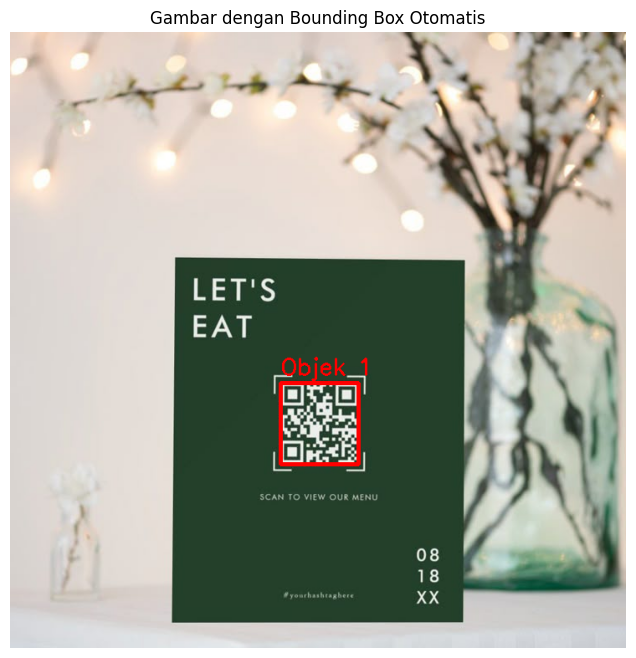

True

In [12]:
# Gunakan edges dari Canny untuk mencari contours
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Buat copy gambar untuk menggambar bounding box
img_bbox = img_rgb.copy()

# Filter contours berdasarkan area (ambil yang cukup besar)
min_area = 777 # Area minimum untuk dianggap objek utama (Semakin kecil nilainya, semakin banyak yang ditangkap)
valid_contours = [cnt for cnt in contours if cv2.contourArea(cnt) > min_area]

print(f"✓ Ditemukan {len(valid_contours)} objek dengan area > {min_area}")

# Gambar bounding box untuk setiap contour yang valid
for i, contour in enumerate(valid_contours):
    # Dapatkan koordinat bounding box
    x, y, w, h = cv2.boundingRect(contour)
    
    # Gambar rectangle
    cv2.rectangle(img_bbox, (x, y), (x+w, y+h), color=(255, 0, 0), thickness=3)
    
    # Tambahkan label
    cv2.putText(img_bbox, f'Objek {i+1}', (x, y-10), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 0, 0), 2)

# Tampilkan hasil bounding box
plt.figure(figsize=(12, 8))
plt.imshow(img_bbox)
plt.title('Gambar dengan Bounding Box Otomatis')
plt.axis('off')
plt.show()

# Simpan hasil
cv2.imwrite('results_ws4/hasil_bounding_box.jpg', cv2.cvtColor(img_bbox, cv2.COLOR_RGB2BGR))

**E. Menerapkan Filter Blur & Sharpening**

✓ Filter Blur berhasil diterapkan
✓ Filter Sharpening berhasil diterapkan


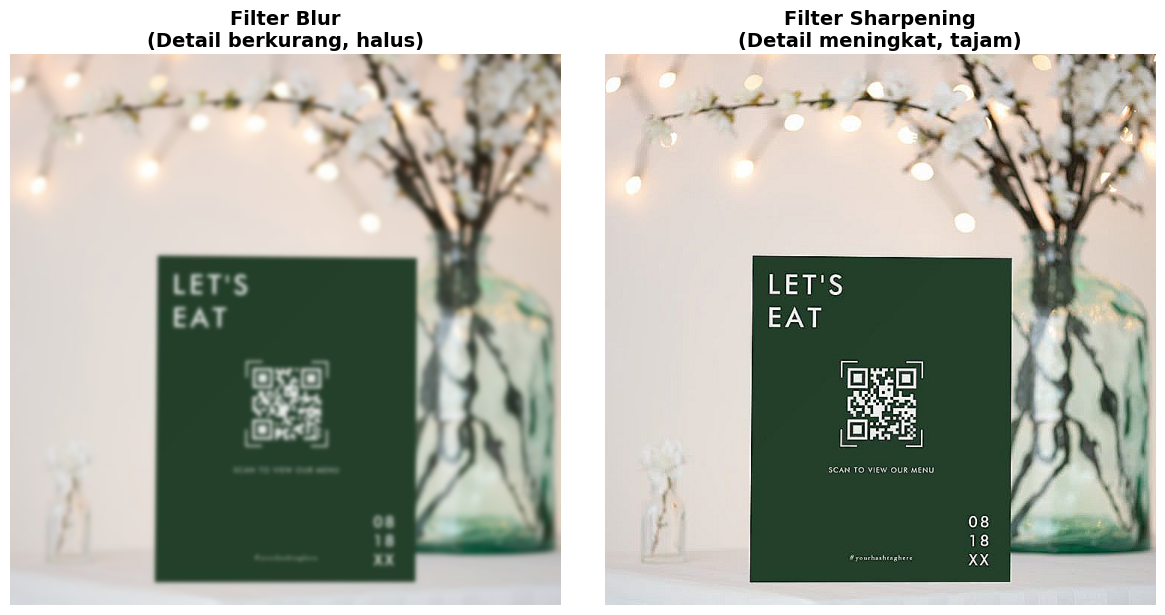

In [13]:
# 1. Filter Blur
# Terapkan Gaussian Blur dengan kernel size (15, 15) => semakin besar, semakin blur
img_blurred = cv2.GaussianBlur(img_rgb, (15, 15), sigmaX=0)

print("✓ Filter Blur berhasil diterapkan")

# Definisikan kernel sharpening
kernel_sharpen = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])

# 2. Filter Sharpening
# Terapkan filter sharpening menggunakan filter2D
img_sharpened = cv2.filter2D(img_rgb, -1, kernel_sharpen)

print("✓ Filter Sharpening berhasil diterapkan")

# Tampilkan hasil Blur dan Sharpening
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 2)
plt.imshow(img_blurred)
plt.title('Filter Blur\n(Detail berkurang, halus)', fontsize=14, fontweight='bold')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_sharpened)
plt.title('Filter Sharpening\n(Detail meningkat, tajam)', fontsize=14, fontweight='bold')
plt.axis('off')

plt.tight_layout()
plt.savefig('results_ws4/perbandingan_filter.jpg', dpi=150, bbox_inches='tight')
plt.show()

**F. Penjelasan Dampak Filter terhadap Detail Gambar**  
Dari deteksi tepi dan beberapa filter yang telah dilakukan, berikut adalah penjelasan dari dampaknya:

**1. Canny Edge Detection** => Digunakan untuk **mendeteksi tepi/garis** batas objek, biasanya untuk **deteksi kontur**. Dampaknya menghasilkan **outline** objek.

**2. Thresholding** => Digunakan untuk memisahkan pixel menjadi 2 kelompok **hitam (0)** & **putih (255)**. Dampaknya menyederhanakan gambar menjadi **binary** untuk memudahkan **segmentasi** objek.

**3. Bounding Box** => Digunakan untuk **menandai** area objek dengan **kotak pembatas**. Dampaknya menghasilkan **kotak pembatas** di sekitar **objek** hasil **segmentasi**.

**4. Filter Blur** => Digunakan **sebelum** melakukan **edge detection**. Dampaknya **detail** gambar **berkurang**, namun **tekstur** gambar menjadi **halus**.

**5. Filter Sharpening** => Digunakan untuk **meningkatkan kualitas gambar**. Dampaknya **gambar** menjadi lebih **tajam** & **mempertajam detail halus**.

---

### **Soal 4 — Deteksi Wajah dan Filter Digital Kreatif**

* Ambil gambar diri Anda dengan ekspresi wajah **netral**.
* Lakukan **deteksi wajah dan landmark** menggunakan salah satu dari:

  * **MediaPipe**, atau
  * **Dlib**, atau
  * **OpenCV**.
* Buat **overlay filter digital kreatif** karya Anda sendiri, misalnya:

  * topi, kumis, masker, helm, aksesoris, atau bentuk unik lainnya.
  * Filter boleh dibuat dari **gambar eksternal (PNG)** *atau* digambar langsung (misal bentuk lingkaran, garis, poligon, dll).
* Pastikan posisi overlay menyesuaikan **landmark wajah** dengan logis.
* **Gunakan alpha blending sebagai saran** agar hasil tampak lebih natural.
* Tampilkan perbandingan antara **gambar asli** dan **hasil dengan filter**.
* Jelaskan bagaimana Anda menghitung posisi overlay dan tantangan yang dihadapi selama implementasi (gunakan **Markdown**).

**A. Import Library (Mediapipe) & Load Gambar**

✓ MediaPipe berhasil diimport
✓ Gambar berhasil dibaca dengan ukuran: (4608, 2592, 3)


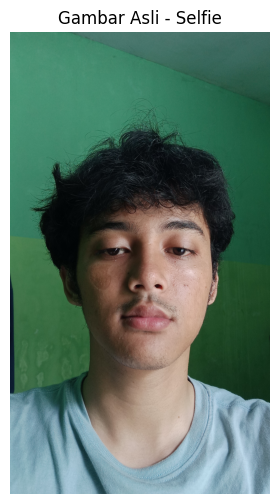

In [14]:
import mediapipe as mp

# Inisialisasi MediaPipe Face Mesh
mp_face_mesh = mp.solutions.face_mesh
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles

print("✓ MediaPipe berhasil diimport")

# Baca gambar selfie
img = cv2.imread(os.path.join(os.getcwd(), "assets_ws4", "selfie.jpg"))

# Konversi BGR ke RGB (MediaPipe butuh RGB)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Buat copy untuk hasil akhir
img_with_filter = img_rgb.copy()

print(f"✓ Gambar berhasil dibaca dengan ukuran: {img_rgb.shape}")

# Tampilkan gambar asli
plt.figure(figsize=(8, 6))
plt.imshow(img_rgb)
plt.title('Gambar Asli - Selfie')
plt.axis('off')
plt.show()

**B. Deteksi Wajah dan Landmark dengan MediaPipe**

In [15]:
# Inisialisasi Face Mesh
with mp_face_mesh.FaceMesh(
    static_image_mode=True,  # Untuk gambar statis
    max_num_faces=1,  # Deteksi 1 wajah
    refine_landmarks=True,  # Landmark lebih detail
    min_detection_confidence=0.5
) as face_mesh:
    
    # Proses gambar
    results = face_mesh.process(img_rgb)
    
    # Cek apakah wajah terdeteksi
    if not results.multi_face_landmarks:
        print("❌ Wajah tidak terdeteksi!")
    else:
        print(f"✓ Wajah terdeteksi! Total landmark: {len(results.multi_face_landmarks[0].landmark)}")

✓ Wajah terdeteksi! Total landmark: 478


**C. Membuat Filter Kacamata**
- **Langkah 1 => Ekstrak Koordinat Landmark untuk Kacamata**   
Landmark penting untuk kacamata:  
    + **Mata Kiri**: landmark 33 (sudut luar), 133 (sudut dalam)  
    + **Mata Kanan**: landmark 362 (sudut luar), 263 (sudut dalam)  
    + **Batang Hidung**: landmark 168  

In [16]:
# Fungsi helper untuk konversi landmark ke koordinat pixel
def get_landmark_coords(landmark, img_width, img_height):
    """Konversi normalized landmark ke koordinat pixel"""
    x = int(landmark.x * img_width)
    y = int(landmark.y * img_height)
    return (x, y)

# Ambil dimensi gambar
h, w, _ = img_rgb.shape

if results.multi_face_landmarks:
    # Ambil landmark wajah pertama
    face_landmarks = results.multi_face_landmarks[0]
    
    # Ekstrak koordinat landmark mata
    # Mata Kiri
    left_eye_outer = get_landmark_coords(face_landmarks.landmark[33], w, h)  # Sudut luar
    left_eye_inner = get_landmark_coords(face_landmarks.landmark[133], w, h)  # Sudut dalam
    left_eye_top = get_landmark_coords(face_landmarks.landmark[159], w, h)  # Atas
    left_eye_bottom = get_landmark_coords(face_landmarks.landmark[145], w, h)  # Bawah
    
    # Mata Kanan
    right_eye_outer = get_landmark_coords(face_landmarks.landmark[362], w, h)  # Sudut luar
    right_eye_inner = get_landmark_coords(face_landmarks.landmark[263], w, h)  # Sudut dalam
    right_eye_top = get_landmark_coords(face_landmarks.landmark[386], w, h)  # Atas
    right_eye_bottom = get_landmark_coords(face_landmarks.landmark[374], w, h)  # Bawah
    
    # Batang hidung (untuk posisi tengah kacamata)
    nose_bridge = get_landmark_coords(face_landmarks.landmark[6], w, h)
    
    print("✓ Koordinat landmark mata berhasil diekstrak")
    print(f"  Mata Kiri (luar): {left_eye_outer}")
    print(f"  Mata Kanan (luar): {right_eye_outer}")
    print(f"  Batang Hidung: {nose_bridge}")

✓ Koordinat landmark mata berhasil diekstrak
  Mata Kiri (luar): (907, 2193)
  Mata Kanan (luar): (1562, 2185)
  Batang Hidung: (1378, 2201)


- **Langkah 2 => Hitung Dimensi dan Posisi Kacamata**   

In [17]:
# Hitung lebar dan tinggi lensa kacamata
left_eye_width = abs(left_eye_outer[0] - left_eye_inner[0])
left_eye_height = abs(left_eye_top[1] - left_eye_bottom[1])

right_eye_width = abs(right_eye_outer[0] - right_eye_inner[0])
right_eye_height = abs(right_eye_top[1] - right_eye_bottom[1])

# Ukuran lensa (diperbesar sedikit agar terlihat seperti kacamata)
lens_width = int((left_eye_width + right_eye_width) / 2 * 1.5)  # 1.5x lebih besar
lens_height = int((left_eye_height + right_eye_height) / 2 * 1.8)  # 1.8x lebih besar

# Posisi center lensa
left_lens_center = (
    (left_eye_outer[0] + left_eye_inner[0]) // 2,
    (left_eye_top[1] + left_eye_bottom[1]) // 2
)

right_lens_center = (
    (right_eye_outer[0] + right_eye_inner[0]) // 2,
    (right_eye_top[1] + right_eye_bottom[1]) // 2
)

print("✓ Dimensi kacamata dihitung")
print(f"  Ukuran lensa: {lens_width}x{lens_height} pixel")
print(f"  Posisi lensa kiri: {left_lens_center}")
print(f"  Posisi lensa kanan: {right_lens_center}")

✓ Dimensi kacamata dihitung
  Ukuran lensa: 412x132 pixel
  Posisi lensa kiri: (1050, 2188)
  Posisi lensa kanan: (1694, 2185)


- **Langkah 3 => Gambar Filter Kacamata**  
Menggambar kacamata menggunakan shapes OpenCV

In [18]:
# Buat layer overlay untuk alpha blending
overlay = img_with_filter.copy()

# Warna frame kacamata (hitam)
frame_color = (0, 0, 0)
frame_thickness = 3

# Parameter untuk lensa (ellipse)
# Lensa kiri
cv2.ellipse(
    overlay,
    center=left_lens_center,
    axes=(lens_width // 2, lens_height // 1),  # Radius horizontal & vertikal
    angle=0,
    startAngle=0,
    endAngle=360,
    color=frame_color,
    thickness=frame_thickness
)

# Lensa kanan
cv2.ellipse(
    overlay,
    center=right_lens_center,
    axes=(lens_width // 2, lens_height // 1),
    angle=0,
    startAngle=0,
    endAngle=360,
    color=frame_color,
    thickness=frame_thickness
)

# Gambar bridge (batang penghubung di hidung)
cv2.line(
    overlay,
    pt1=left_lens_center,  # Dari lensa kiri
    pt2=right_lens_center,  # Ke lensa kanan
    color=frame_color,
    thickness=frame_thickness
)

# Gambar gagang kacamata (temple arms)
# Gagang kiri
temple_left_end = (left_eye_outer[0] - lens_width // 2, left_lens_center[1])
cv2.line(
    overlay,
    pt1=left_lens_center,
    pt2=temple_left_end,
    color=frame_color,
    thickness=frame_thickness
)

# Gagang kanan
temple_right_end = (right_eye_outer[0] + lens_width // 2, right_lens_center[1])
cv2.line(
    overlay,
    pt1=right_lens_center,
    pt2=temple_right_end,
    color=frame_color,
    thickness=frame_thickness
)

print("✓ Filter kacamata berhasil digambar")

✓ Filter kacamata berhasil digambar


- **Langkah 4 => Terapkan Alpha Blending**  
Alpha blending membuat kacamata terlihat semi-transparan dan natural.  
**alpha = 0.7**: kacamata 70% terlihat, gambar asli 30% terlihat

In [19]:
# Alpha blending: menggabungkan overlay dengan gambar asli
alpha = 0.7  # Transparansi overlay (0.0 = transparan penuh, 1.0 = opaque penuh)

# Formula: output = overlay * alpha + original * (1 - alpha)
img_with_filter = cv2.addWeighted(overlay, alpha, img_with_filter, 1 - alpha, 0)

print("✓ Alpha blending berhasil diterapkan")

✓ Alpha blending berhasil diterapkan


- **Langkah 5 => Menambahkan Efek Lensa** 

In [20]:
# Tambahkan efek tint pada lensa (seperti kacamata hitam)
# Buat mask untuk area lensa
mask_left = np.zeros((h, w), dtype=np.uint8)
mask_right = np.zeros((h, w), dtype=np.uint8)

# Isi mask dengan ellipse
cv2.ellipse(mask_left, left_lens_center, (lens_width // 2, lens_height // 1), 
            0, 0, 360, 255, -1)  # -1 = filled
cv2.ellipse(mask_right, right_lens_center, (lens_width // 2, lens_height // 1), 
            0, 0, 360, 255, -1)

# Gabungkan mask
mask_lenses = cv2.bitwise_or(mask_left, mask_right)

# Terapkan tint gelap pada area lensa
tint_color = np.array([40, 40, 40], dtype=np.uint8)  # Tint gelap
img_with_filter[mask_lenses > 0] = cv2.addWeighted(
    img_with_filter[mask_lenses > 0], 0.4,  # Gambar asli 40%
    np.full_like(img_with_filter[mask_lenses > 0], tint_color), 0.7,  # Tint 60%
    0
)

print("✓ Efek tint lensa diterapkan")

✓ Efek tint lensa diterapkan


**D. Menampilkan Perbandingan Hasil**

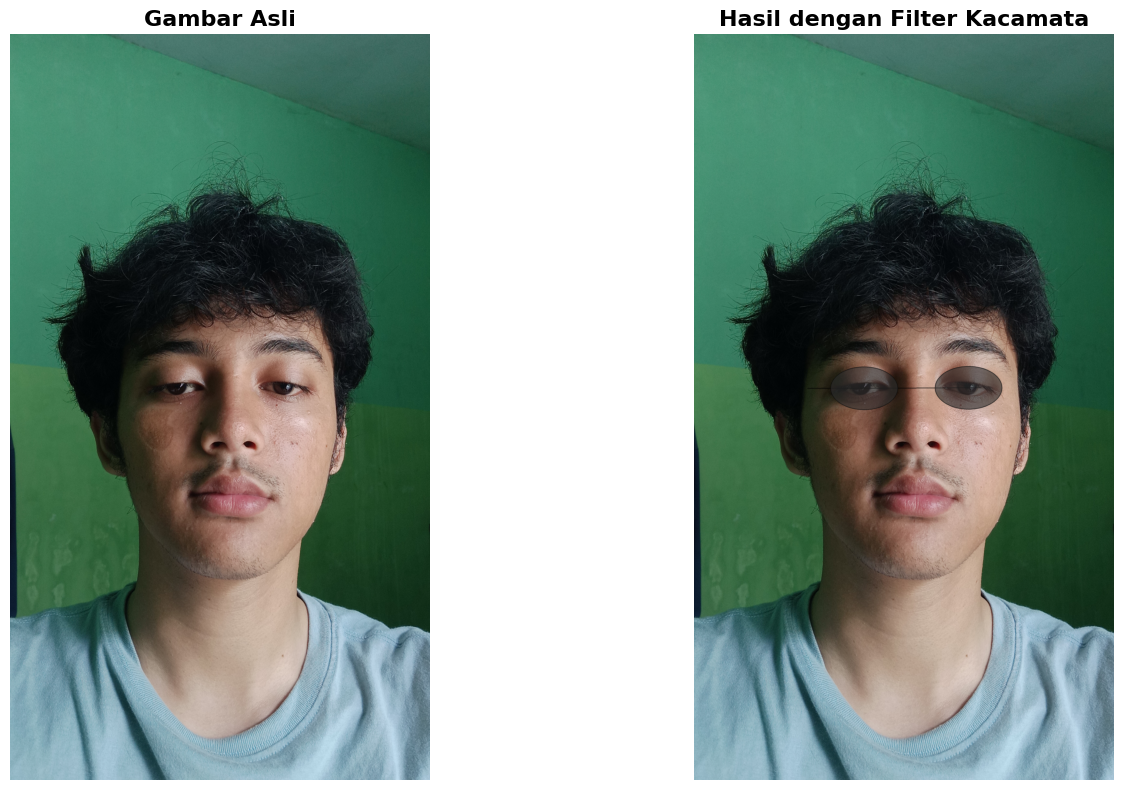

✓ Perbandingan berhasil ditampilkan dan disimpan


In [21]:
# Tampilkan perbandingan side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Gambar asli
axes[0].imshow(img_rgb)
axes[0].set_title('Gambar Asli', fontsize=16, fontweight='bold')
axes[0].axis('off')

# Gambar dengan filter kacamata
axes[1].imshow(img_with_filter)
axes[1].set_title('Hasil dengan Filter Kacamata', fontsize=16, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('results_ws4/filter_kacamata.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Perbandingan berhasil ditampilkan dan disimpan")

**E. Penjelasan Implementasi Filter Kacamata**  

**1. Cara Menghitung Posisi Overlay**  

A. Deteksi Landmark Mata:
- Landmark mata kiri: **33** (sudut luar), **133** (sudut dalam), **159** (atas), **145** (bawah)
- Landmark mata kanan: **362** (sudut luar), **263** (sudut dalam), **386** (atas), **374** (bawah)
- Landmark batang hidung: **6** (untuk posisi bridge kacamata)

B. Perhitungan Dimensi Lensa:
```
lebar_lensa = rata-rata(lebar_mata_kiri, lebar_mata_kanan) × 1.5
tinggi_lensa = rata-rata(tinggi_mata_kiri, tinggi_mata_kanan) × 1.8
```
- Dikali 1.5 dan 1.8 agar lensa lebih besar dari mata (seperti kacamata sungguhan)

C. Posisi Center Lensa
```
center_lensa_kiri = titik_tengah(sudut_luar, sudut_dalam, atas, bawah)
center_lensa_kanan = titik_tengah(sudut_luar, sudut_dalam, atas, bawah)
```

D. Komponen Kacamata yang Digambar
1. **Lensa kiri & kanan**: Ellipse dengan `cv2.ellipse()`
2. **Bridge** (batang hidung): Garis penghubung antara 2 lensa dengan `cv2.line()`
3. **Temple arms** (gagang): Garis dari lensa ke samping wajah

---

**2. Tantangan yang Dihadapi**

A. Akurasi Landmark
- **Masalah**: Landmark bisa sedikit tidak akurat jika pencahayaan buruk atau pose ekstrem
- **Solusi**: Gunakan `refine_landmarks=True` dan pastikan foto dengan pencahayaan baik

B. Ukuran Lensa yang Proporsional
- **Masalah**: Lensa terlalu kecil/besar jika hanya menggunakan ukuran mata
- **Solusi**: Tambahkan faktor pengali (1.5x untuk lebar, 1.8x untuk tinggi) melalui trial-error

C. Posisi Bridge yang Tepat
- **Masalah**: Bridge bisa tidak pas di batang hidung jika hanya menghubungkan center lensa
- **Solusi**: Gunakan landmark batang hidung (6) sebagai referensi tambahan

D. Alpha Blending yang Natural
- **Masalah**: Kacamata terlihat terlalu solid atau terlalu transparan
- **Solusi**: Eksperimen dengan nilai alpha (0.6-0.8 paling optimal)

---

### **Soal 5 — Perspektif dan Peningkatan Kualitas Citra**

* Ambil gambar **objek datar** seperti karya tangan di kertas, tulisan di papan tulis, atau foto produk di meja dengan kondisi pencahayaan atau sudut yang tidak ideal.
* Lakukan **preprocessing** untuk memperbaiki tampilan agar lebih rapi dan jelas, dengan langkah-langkah:

  * Konversi ke **grayscale**.
  * **Koreksi perspektif (transformasi homografi)** menggunakan **4 titik manual** agar objek terlihat sejajar dan tidak terdistorsi.
  * Terapkan **thresholding adaptif atau Otsu** (pilih salah satu, dan jelaskan alasan pilihan Anda).
* Tampilkan **setiap tahap pemrosesan dalam satu grid** agar mudah dibandingkan.
* Jelaskan fungsi masing-masing tahap dan bagaimana teknik ini meningkatkan kualitas visual citra (gunakan **Markdown**).

**A. Load Gambar**

✓ Gambar berhasil dibaca dengan ukuran: 2296x4080


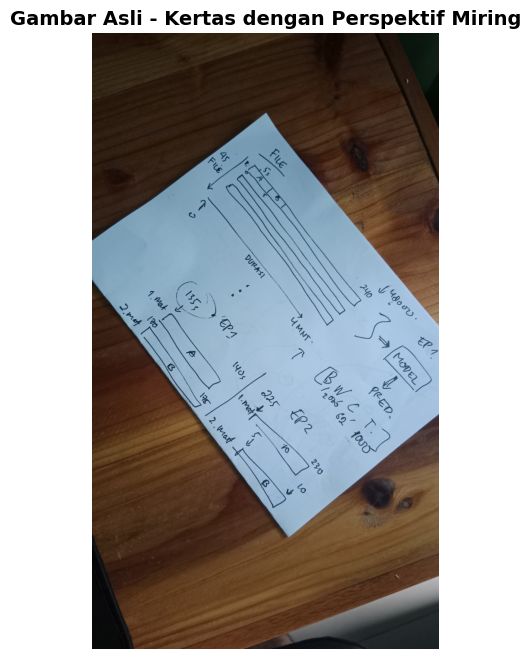

In [22]:
# Baca gambar
img = cv2.imread('assets_ws4/tulisan_kertas.jpg')

# Konversi BGR ke RGB untuk tampilan
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Simpan dimensi asli
original_height, original_width = img.shape[:2]

print(f"✓ Gambar berhasil dibaca dengan ukuran: {original_width}x{original_height}")

# Tampilkan gambar asli
plt.figure(figsize=(10, 8))
plt.imshow(img_rgb)
plt.title('Gambar Asli - Kertas dengan Perspektif Miring', fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

**B. Konversi ke Grayscale**

✓ Konversi ke grayscale berhasil


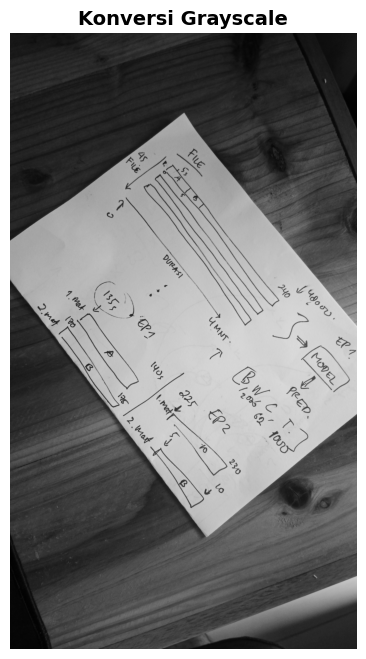

In [23]:
# Konversi ke grayscale
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

print("✓ Konversi ke grayscale berhasil")

# Tampilkan hasil grayscale
plt.figure(figsize=(10, 8))
plt.imshow(img_gray, cmap='gray')
plt.title('Konversi Grayscale', fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

**C. Deteksi Tepi untuk Membantu Menemukan Kontur Kertas**

✓ Deteksi tepi selesai


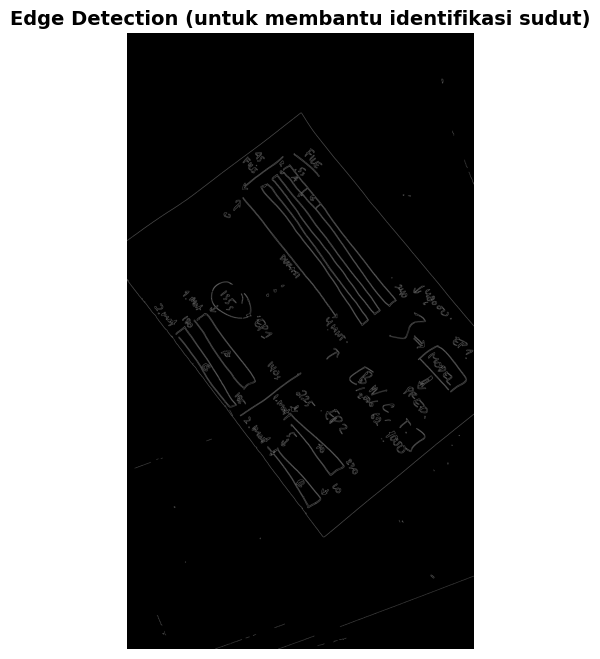

In [24]:
# Aplikasikan Gaussian Blur untuk mengurangi noise
blurred = cv2.GaussianBlur(img_gray, (5, 5), 0)

# Deteksi tepi dengan Canny
edges = cv2.Canny(blurred, 50, 100)

print("✓ Deteksi tepi selesai")

# Tampilkan edge detection
plt.figure(figsize=(10, 8))
plt.imshow(edges, cmap='gray')
plt.title('Edge Detection (untuk membantu identifikasi sudut)', fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

**D. Pilih 4 Titik Sudut Kertas Secara Manual**  
Memilih 4 titik sudut kertas untuk transformasi perspektif.  
Urutan: Top-Left, Top-Right, Bottom-Right, Bottom-Left.

✓ Menggunakan koordinat manual
4 titik sudut: [[   0. 1400.]
 [1130.  550.]
 [2500. 2200.]
 [1300. 3320.]]


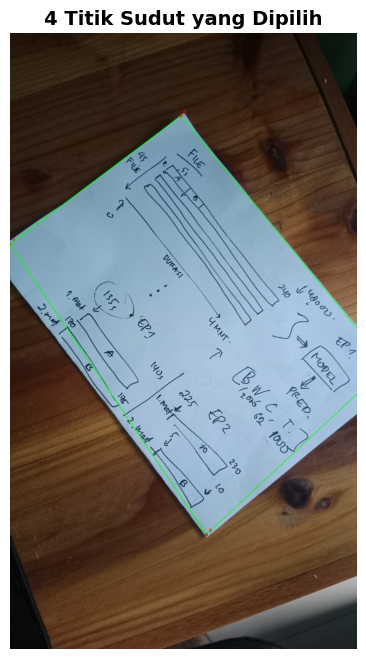

In [25]:
src_points = np.float32([
    [0, 1400],   # Top-Left (kiri atas)
    [1130, 550],   # Top-Right (kanan atas)
    [2500, 2200],  # Bottom-Right (kanan bawah)
    [1300, 3320]   # Bottom-Left (kiri bawah)
])

print("✓ Menggunakan koordinat manual")
print(f"4 titik sudut: {src_points}")

# Visualisasi titik yang dipilih
img_with_points = img_rgb.copy()
for i, point in enumerate(src_points):
    x, y = int(point[0]), int(point[1])
    cv2.circle(img_with_points, (x, y), 10, (255, 0, 0), -1)
    cv2.putText(img_with_points, str(i+1), (x+15, y-15),
               cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 3)

# Gambar garis penghubung
cv2.polylines(img_with_points, [src_points.astype(np.int32)], 
              isClosed=True, color=(0, 255, 0), thickness=3)

plt.figure(figsize=(10, 8))
plt.imshow(img_with_points)
plt.title('4 Titik Sudut yang Dipilih', fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

**E. Hitung Dimensi Output dan Titik Tujuan**

In [26]:
# Hitung lebar dan tinggi kertas hasil perspektif
# Lebar: jarak antara top-left ke top-right
width_top = np.linalg.norm(src_points[0] - src_points[1])
width_bottom = np.linalg.norm(src_points[3] - src_points[2])
max_width = int(max(width_top, width_bottom))

# Tinggi: jarak antara top-left ke bottom-left
height_left = np.linalg.norm(src_points[0] - src_points[3])
height_right = np.linalg.norm(src_points[1] - src_points[2])
max_height = int(max(height_left, height_right))

print(f"✓ Dimensi output: {max_width}x{max_height} pixel")

# Definisikan titik tujuan (rectangle sempurna)
dst_points = np.float32([
    [0, 0],                      # Top-Left
    [max_width - 1, 0],          # Top-Right
    [max_width - 1, max_height - 1],  # Bottom-Right
    [0, max_height - 1]          # Bottom-Left
])

✓ Dimensi output: 1641x2318 pixel


**F. Lakukan Transformasi Perspektif**

✓ Transformasi perspektif berhasil dilakukan


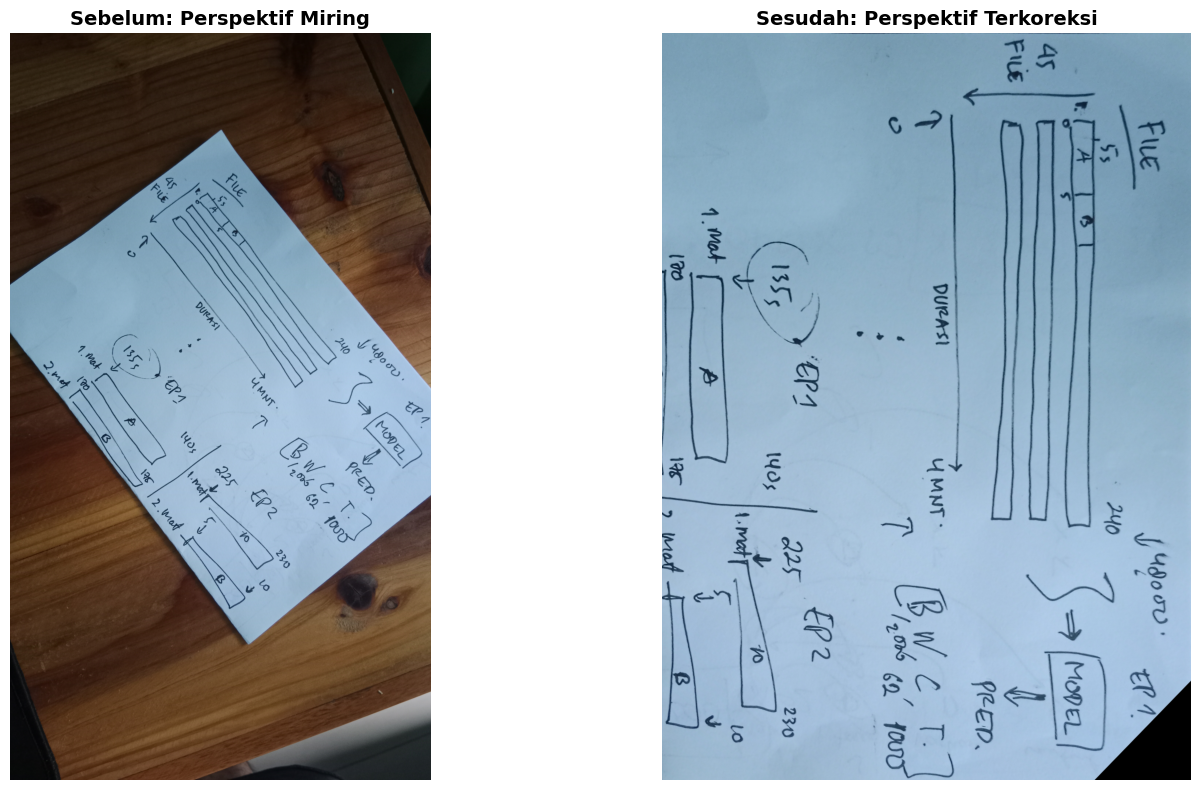

In [27]:
# Hitung perspective transformation matrix
perspective_matrix = cv2.getPerspectiveTransform(src_points, dst_points)

# Terapkan transformasi perspektif ke gambar asli (RGB)
img_warped_rgb = cv2.warpPerspective(img_rgb, perspective_matrix, 
                                     (max_width, max_height))

# Terapkan juga ke grayscale
img_warped_gray = cv2.warpPerspective(img_gray, perspective_matrix, 
                                      (max_width, max_height))

print("✓ Transformasi perspektif berhasil dilakukan")

# Tampilkan hasil koreksi perspektif
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(img_rgb)
axes[0].set_title('Sebelum: Perspektif Miring', fontsize=14, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(img_warped_rgb)
axes[1].set_title('Sesudah: Perspektif Terkoreksi', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

**G. Terapkan Thresholding OTSU**  
**Alasan**: Saya memilih **Thresholding OTSU** karena **pencahayaannya lebih merata** seperti menggunakan **cam-scanner**.

✓ Adaptive Threshold selesai
✓ Otsu Threshold selesai


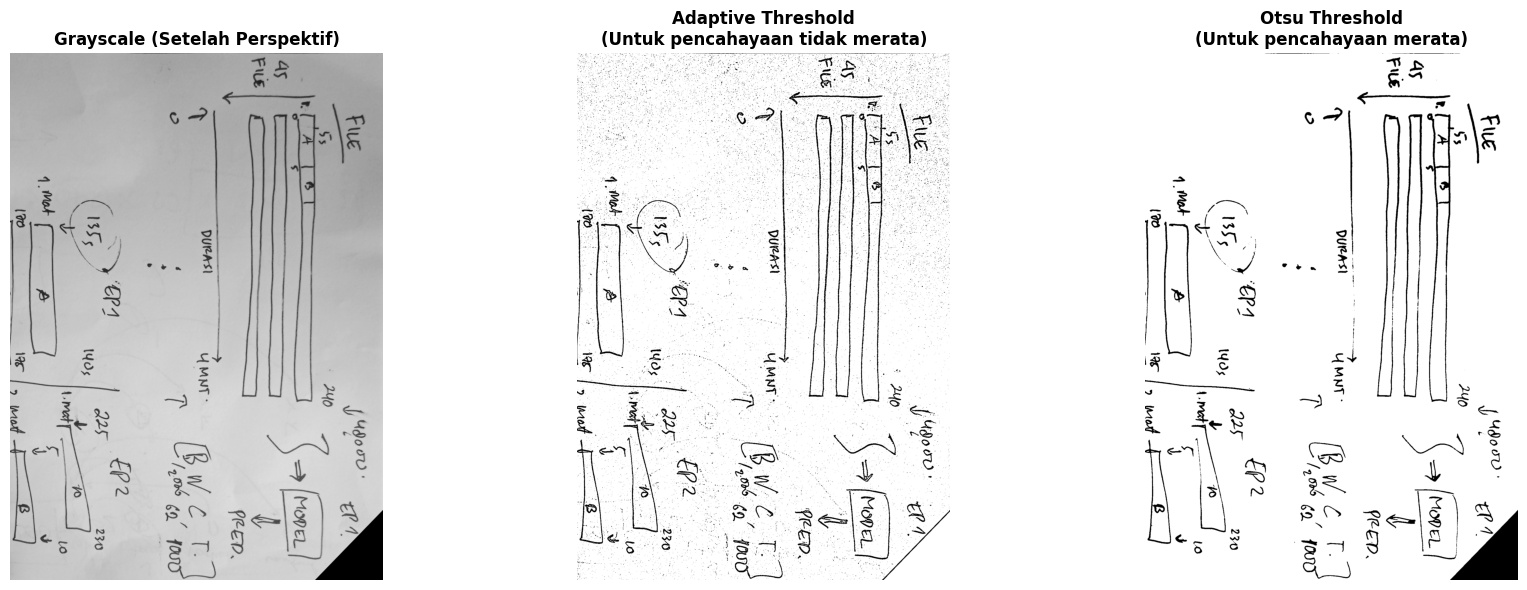

True

In [28]:
# A. ADAPTIVE THRESHOLD (untuk pencahayaan tidak merata)
img_adaptive = cv2.adaptiveThreshold(
    img_warped_gray,
    maxValue=255,
    adaptiveMethod=cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    thresholdType=cv2.THRESH_BINARY,
    blockSize=11,  # Ukuran area untuk hitung threshold lokal
    C=2  # Konstanta pengurangan dari mean
)

print("✓ Adaptive Threshold selesai")

# B. OTSU THRESHOLD (untuk pencahayaan merata)
_, img_otsu = cv2.threshold(
    img_warped_gray,
    thresh=0,  # Akan dihitung otomatis oleh Otsu
    maxval=255,
    type=cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

print("✓ Otsu Threshold selesai")

# Tampilkan perbandingan kedua metode
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img_warped_gray, cmap='gray')
axes[0].set_title('Grayscale (Setelah Perspektif)', fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(img_adaptive, cmap='gray')
axes[1].set_title('Adaptive Threshold\n(Untuk pencahayaan tidak merata)', fontsize=12, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(img_otsu, cmap='gray')
axes[2].set_title('Otsu Threshold\n(Untuk pencahayaan merata)', fontsize=12, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

# Simpan hasil akhir
cv2.imwrite('results_ws4/otsu_threshold.jpg', cv2.cvtColor(img_warped_rgb, cv2.COLOR_RGB2BGR))

**H. Menampilkan Semua Tahapan dalam Satu Grid**

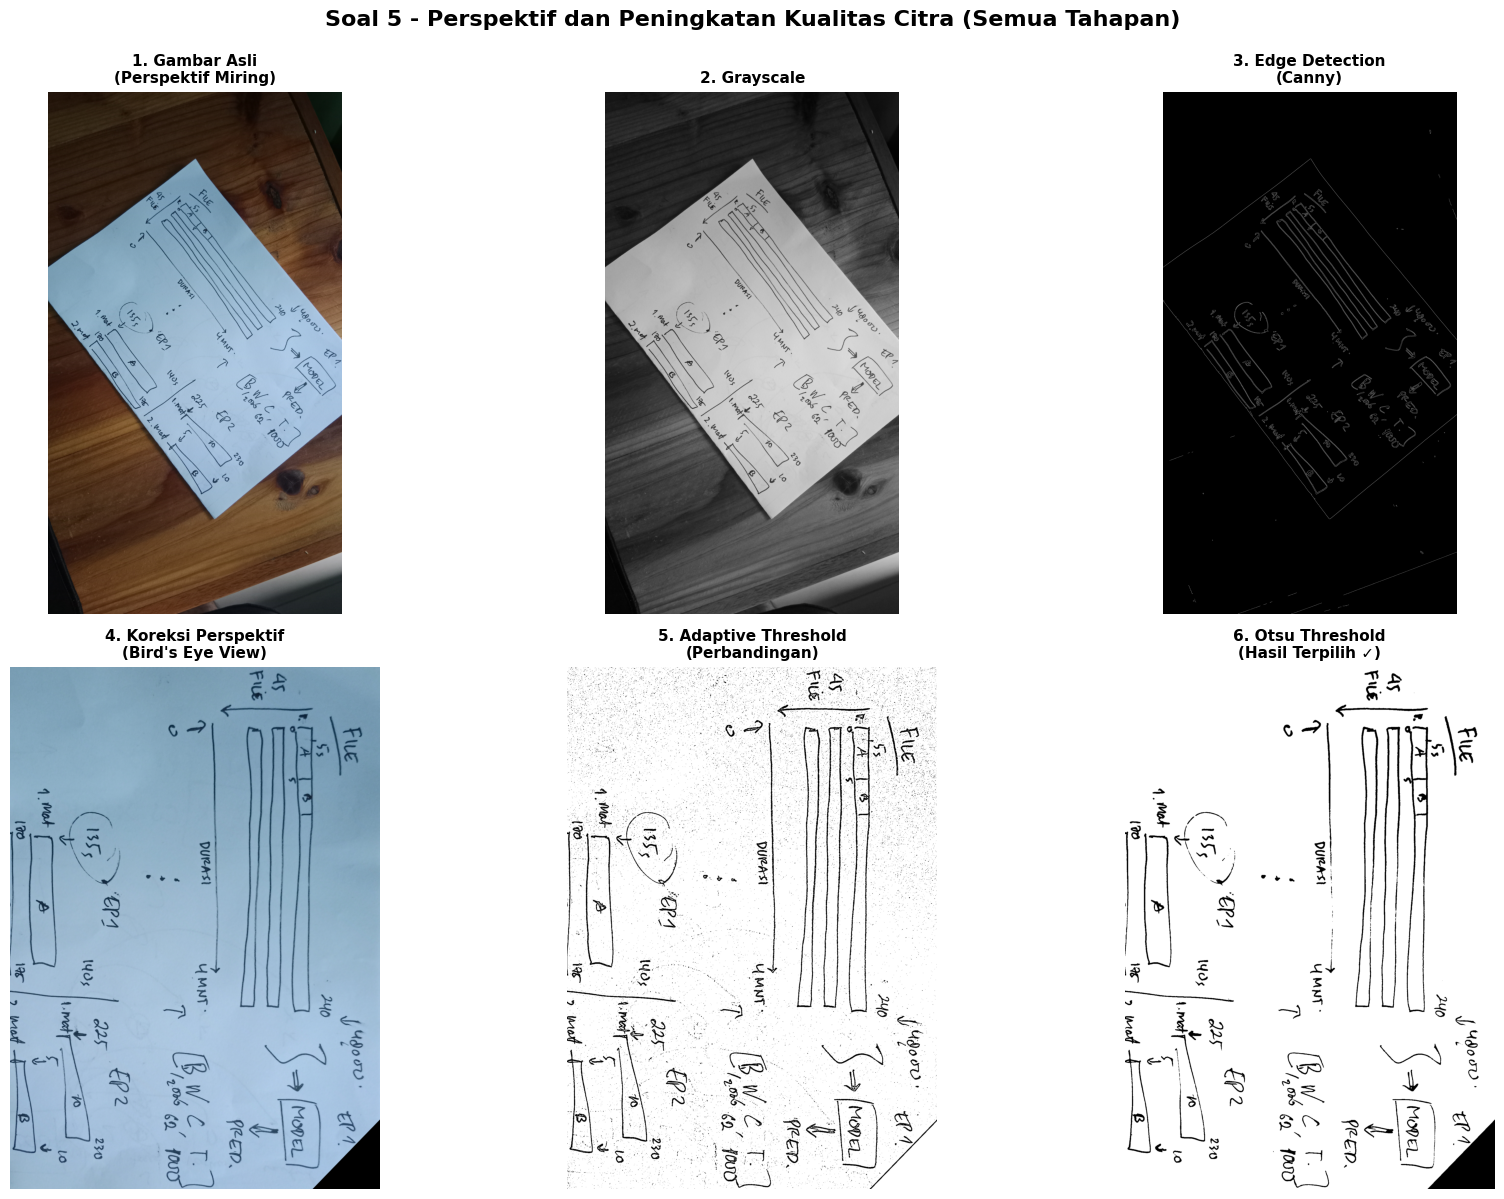

✓ Visualisasi lengkap disimpan sebagai 'results_ws4/tahapan_soal5.jpg'


In [29]:
# Buat visualisasi lengkap semua tahapan
fig = plt.figure(figsize=(18, 12))

# Grid 2x3
# Baris 1: Original, Grayscale, Edge Detection
plt.subplot(2, 3, 1)
plt.imshow(img_rgb)
plt.title('1. Gambar Asli\n(Perspektif Miring)', fontsize=11, fontweight='bold')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(img_gray, cmap='gray')
plt.title('2. Grayscale', fontsize=11, fontweight='bold')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(edges, cmap='gray')
plt.title('3. Edge Detection\n(Canny)', fontsize=11, fontweight='bold')
plt.axis('off')

# Baris 2: Perspective Corrected, Adaptive Threshold, Otsu
plt.subplot(2, 3, 4)
plt.imshow(img_warped_rgb)
plt.title('4. Koreksi Perspektif\n(Bird\'s Eye View)', fontsize=11, fontweight='bold')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(img_adaptive, cmap='gray')
plt.title('5. Adaptive Threshold\n(Perbandingan)', fontsize=11, fontweight='bold')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(img_otsu, cmap='gray')
plt.title('6. Otsu Threshold\n(Hasil Terpilih ✓)', fontsize=11, fontweight='bold')
plt.axis('off')

plt.suptitle('Soal 5 - Perspektif dan Peningkatan Kualitas Citra (Semua Tahapan)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('results_ws4/tahapan_soal5.jpg', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Visualisasi lengkap disimpan sebagai 'results_ws4/tahapan_soal5.jpg'")

**I. Penjelasan Fungsi Setiap Tahap**

Berikut adalah fungsi dari tahap yang dilakukan:    
1. **Konversi Grayscale** => Tahap ini dilakukan untuk **menghilangkan** informasi warna, sehingga mempermudah proses **threshold** dan **mengurangi** kompleksitas data. 

2. **Koreksi Perspektif (Transformasi Homografi)** => Tahap ini dilakukan untuk **mengubah** perspektif gambar dari sudut **miring** menjadi tampak **lurus (bird's eye view)** dengan menggunakan **4 titik** referensi yang dilakukan secara manual.

3. **Penerapan Thresholding** => Di sini saya memilih **Otsu Thresholding** karena tidak perlu menentukan **threshold manual** dan hasilnya mirip seperti **dokumen scan** yang berkualitas baik, karena **pencahayaanya merata**.

Kemudian, **Ringkasan Peningkatan Kualitas Visual** sebagai berikut:  

**Dari Gambar Asli → Hasil Akhir:**
1. **Orientasi**: Miring → Lurus sempurna

2. **Perspektif**: Terdistorsi → Proporsional

3. **Pencahayaan**: Tidak merata → Ternormalisasi

4. **Kontras**: Rendah → Tinggi (hitam-putih tajam)

5. **Keterbacaan**: Sulit → Sangat mudah

6. **Distraksi**: Background mengganggu → Background dihilangkan

---

### **Aturan Umum Pengerjaan**

* Kerjakan secara **mandiri**.
* Bantuan AI (seperti ChatGPT, Copilot, dsb.) diperbolehkan **dengan bukti percakapan** (screenshot / link / script percakapan).
* Source code antar mahasiswa harus berbeda.
* Jika mendapat bantuan teman, tuliskan nama dan NIM teman yang membantu.
* Plagiarisme akan dikenakan sanksi sesuai aturan akademik ITERA.
* Cantumkan seluruh **credit dan referensi** yang digunakan di bagian akhir notebook.
* Penjelasan setiap soal ditulis dalam **Markdown**, bukan di dalam komentar kode.

---

### **Aturan Pengumpulan**

* Semua file kerja Anda (notebook `.ipynb`, gambar, dan hasil) **wajib diunggah ke GitHub repository tugas sebelumnya**.

  * Gunakan struktur folder berikut di dalam repo Anda:

    ```
    /Nama_NIM_Repo/ # Nama repo sebelumnya
      ├── assets_ws4/     # berisi semua gambar atau video asli (input)
      ├── results_ws4/    # berisi semua hasil modifikasi dan output
      ├── worksheet4.ipynb
      └── NIM_Worksheet4.pdf
    ```
* File yang dikumpulkan ke **Tally** hanya berupa **hasil PDF** dari notebook Anda, dengan format nama:

  ```
  NIM_Worksheet4.pdf
  ```
* Pastikan notebook telah dijalankan penuh sebelum diekspor ke PDF.
* Sertakan tautan ke repository GitHub Anda di bagian atas notebook atau di halaman pertama PDF.

---

### ✅ **Catatan Akhir**

> Worksheet 4 ini bertujuan mengasah pemahaman Anda tentang manipulasi citra digital secara praktis. Gunakan kreativitas Anda untuk menghasilkan hasil visual yang menarik dan penjelasan konseptual yang jelas.

---

### **Credit**
1. **Link ChatGPT**   : (https://chatgpt.com/share/69184256-2968-800e-a09f-433cf26d22b2)
2. **Link Claude**    : (https://claude.ai/share/ee0dca7d-fe47-4c4f-947b-39b1b1173938)
3. **Link Gambar QR** : (https://id.pinterest.com/pin/67342956922630147/)